# 02 - Advanced EDA Dashboard

Train-only dashboard for detailed exploratory analysis.

Data scope:
- `product_id`
- `product_name`
- `content_raw`
- `content`
- label columns

Visualizations covered:
- emoji usage by sentiment
- sentiment pie chart
- raw vs clean word-count histogram
- aspect coverage and sentiment structure
- PygWalker exploration
- n-gram dashboards
- word clouds
- 3D TF-IDF + t-SNE projection

In [1]:
from pathlib import Path
import json
import math
import statistics

import emoji
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.manifold import TSNE
from IPython.display import display
from wordcloud import WordCloud

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "preprocessing_pipeline.md").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Cannot locate project root")

ROOT = find_project_root()
DATA_PATH = ROOT / "data/processed/train_clean.json"

df = pd.read_json(DATA_PATH)
keep_cols = [
    "product_id",
    "product_name",
    "content_raw",
    "content",
    "sentiment_llm",
    "as_content",
    "as_physical",
    "as_price",
    "as_packaging",
    "as_delivery",
    "as_service",
]
df = df[keep_cols].copy()
df["product_name"] = df["product_name"].fillna("").astype(str)
df["content_raw"] = df["content_raw"].fillna("").astype(str)
df["content"] = df["content"].fillna("").astype(str)

SENTIMENT_MAP = {
    0: "negative",
    1: "neutral",
    2: "positive",
}
ASPECT_COLS = [
    "as_content",
    "as_physical",
    "as_price",
    "as_packaging",
    "as_delivery",
    "as_service",
]
SENTIMENT_ORDER = ["negative", "neutral", "positive"]
SENTIMENT_COLORS = {
    "negative": "#e45756",
    "neutral": "#f2a541",
    "positive": "#4caf50",
}

print(ROOT)
print(df.shape)
display(df.head(5))

FileNotFoundError: Cannot locate project root

In [ ]:
def avg_word_len(text: str) -> float:
    words = text.split()
    if not words:
        return 0.0
    return float(np.mean([len(word) for word in words]))

def count_emojis(text: str) -> int:
    try:
        return len(emoji.emoji_list(text))
    except Exception:
        return 0

def normalize_text_for_ngrams(text: str) -> str:
    text = text.lower()
    text = " ".join(text.split())
    return text

def sentiment_subset(frame: pd.DataFrame, label: str) -> pd.DataFrame:
    return frame.loc[frame["sentiment_name"] == label].copy()

def top_ngrams(texts, ngram_range=(2, 2), top_n=15):
    vectorizer = CountVectorizer(
        ngram_range=ngram_range,
        token_pattern=r"(?u)\b[\w_]+\b",
        min_df=2,
    )
    matrix = vectorizer.fit_transform(texts)
    if matrix.shape[1] == 0:
        return pd.DataFrame(columns=["ngram", "count"])
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    items = pd.DataFrame(
        {
            "ngram": vectorizer.get_feature_names_out(),
            "count": counts,
        }
    )
    return items.sort_values("count", ascending=False).head(top_n)

In [ ]:
df["sentiment_name"] = df["sentiment_llm"].map(SENTIMENT_MAP).fillna("unknown")
df["raw_word_count"] = df["content_raw"].apply(lambda x: len(x.split()))
df["raw_char_count"] = df["content_raw"].str.len()
df["word_count"] = df["content"].apply(lambda x: len(x.split()))
df["char_count"] = df["content"].str.len()
df["avg_word_len"] = df["content"].apply(avg_word_len)
df["lexical_diversity"] = df["content"].apply(lambda x: len(set(x.split())) / (len(x.split()) + 1))
df["caps_ratio"] = df["content"].apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))
df["emoji_count_raw"] = df["content_raw"].apply(count_emojis)
df["char_delta"] = df["raw_char_count"] - df["char_count"]
df["word_delta"] = df["raw_word_count"] - df["word_count"]
df["review_length_bucket"] = pd.cut(
    df["char_count"],
    bins=[0, 10, 20, 50, 100, 200, 500, 10_000],
    right=False,
)

display(
    df[
        [
            "product_id",
            "product_name",
            "sentiment_name",
            "content_raw",
            "content",
            "word_count",
            "char_count",
            "avg_word_len",
            "lexical_diversity",
            "caps_ratio",
    ]
].head(8)
)

,product_id,product_name,sentiment_name,content_raw,content,word_count,char_count,avg_word_len,lexical_diversity,caps_ratio
0,277357492,Sách Ehon - Đi Đã Ngoại Ngày Mưa,positive,"Seri truyện của tác giả này bé nhà mình có đủ, sách đẹp, nội dung lý thú","Seri truyện của tác giả này bé nhà mình có đủ, sách đẹp, nội dung lý thú",17,72,3.294118,0.944444,0.013699
1,6683795,Sách Ăn Bẩn Sống Lâu,negative,Hình như dịch vụ vận chuyển của Tiki ngày càng kém đi. Trước ở Hà Nội chưa có đơn hàng nào mình chưa hài lòng. Nhưng từ khi vào Nha Tran...,Hình như dịch vụ vận chuyển của Tiki ngày càng kém đi. Trước ở Hà Nội chưa có đơn hàng nào mình chưa hài lòng. Nhưng từ khi vào Nha Tran...,134,595,3.447761,0.755556,0.023490
2,2208831,Sách tương tác tiếng Anh - Usborne First Maths Slide and See Adding at the Circus,positive,"Sản phẩm hơi cũ và ố ơ cạnh trang sách, nhưng không ảnh hưởng tổng thế. Có thể là sách cụ nên có mức giá giảm nhẹ. Tạm chấp nhận.\n\nNội...","Sản phẩm hơi cũ và ố ơ cạnh trang sách, nhưng không ảnh hưởng tổng thế. Có thể là sách cụ nên có mức giá giảm nhẹ. Tạm chấp nhận. Nội du...",40,169,3.250000,0.951220,0.023529
3,17336364,Sách Phía Sau Nghi Can X (Tái Bản 2019),negative,"Không phải nội dung, ở đây là bìa sách và ruột sách. Cũ kỹ, bụi bặm và rách nát..như hàng trưng bày bán ế lâu năm. Đề nghị Tiki ngừng hợ...","Không phải nội dung, ở đây là bìa sách và ruột sách. Cũ kỹ, bụi bặm và rách nát..như hàng trưng bày bán ế lâu năm. Đề nghị Tiki ngừng hợ...",54,240,3.462963,0.945455,0.024896
4,7839316,Combo nuôi con không phải cuộc chiến bộ 4 cuốn,neutral,"Sản phẩm ok, dùng được ....","Sản phẩm ok, dùng được ..",6,25,3.333333,0.857143,0.038462
5,3304875,Sách Điều Kỳ Diệu Của Tiệm Tạp Hóa NAMIYA (Tái Bản),neutral,"Sách hay, siêu đẹp, mới tinh. Nhưng đánh giá 3 sao cho TIKI nhìn thấy và mong TIKI rút kinh nghiệm, một hộp 4q sách to nhỏ khác nhau mà ...","Sách hay, siêu đẹp, mới tinh. Nhưng đánh giá 3 sao cho TIKI nhìn thấy và mong TIKI rút kinh nghiệm, một hộp 4q sách to nhỏ khác nhau mà ...",56,246,3.410714,0.877193,0.040486
6,45663008,Sách Ngày Xưa Có Một Con Bò…(Tái Bản),neutral,"Sách đẹp Nội đúng chưa xem,","Sách đẹp Nội đúng chưa xem,",6,27,3.666667,0.857143,0.071429
7,392568,Sách Marvellous Techniques For IELTS Writing,neutral,"Sách đưa ra nhiều mặt của vấn đề để người học dựa vào đó mà phát triển ý, nhất là task 2. Tuy nhiên task 1 sách viết hơi sơ sài. Bạn nào...","Sách đưa ra nhiều mặt của vấn đề để người học dựa vào đó mà phát triển ý, nhất là task 2. Tuy nhiên task 1 sách viết hơi sơ sài. Bạn nào...",50,204,3.100000,0.862745,0.014634


## Random Review Explorer

In [ ]:
random_idx = np.random.RandomState(42).choice(df.index)
sample_row = df.loc[random_idx]
same_product = df.loc[df["product_id"] == sample_row["product_id"]].copy()
review_key = sample_row.get("review_id", random_idx)

print(f"review_id: {review_key}")
print(f"product_id: {sample_row['product_id']}")
print(f"product_name: {sample_row['product_name']}")
print(f"sentiment: {sample_row['sentiment_name']}")
print("\nRAW:")
print(sample_row["content_raw"])
print("\nCLEAN:")
print(sample_row["content"])
print(f"\nSame product reviews: {len(same_product)}")

aspect_values = sample_row[ASPECT_COLS].fillna(0).astype(float).tolist()
radar_theta = ASPECT_COLS + [ASPECT_COLS[0]]
radar_r = aspect_values + [aspect_values[0]]

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "polar"}, {"type": "bar"}]],
    subplot_titles=("Aspect profile", "Label snapshot"),
    horizontal_spacing=0.15,
)

fig.add_trace(
    go.Scatterpolar(
        r=radar_r,
        theta=radar_theta,
        fill="toself",
        name="aspects",
        line_color="#2d6cdf",
        showlegend=False,
    ),
    row=1,
    col=1,
)

label_snapshot = pd.DataFrame(
    {
        "label": ["sentiment", "word_count", "char_count", "emoji_count_raw"],
        "value": [
            float(sample_row["sentiment_llm"]),
            float(sample_row["word_count"]),
            float(sample_row["char_count"]),
            float(sample_row["emoji_count_raw"]),
        ],
    }
)
fig.add_trace(
    go.Bar(
        x=label_snapshot["label"],
        y=label_snapshot["value"],
        marker_color=["#e45756", "#2d6cdf", "#2d6cdf", "#4caf50"],
        showlegend=False,
    ),
    row=1,
    col=2,
)
fig.update_layout(template="plotly_white", title="Random review explorer")
fig.show()

if len(same_product) > 1:
    product_summary = (
        same_product.groupby("sentiment_name")
        .size()
        .reindex(SENTIMENT_ORDER)
        .fillna(0)
        .reset_index(name="count")
    )
    fig = px.bar(
        product_summary,
        x="sentiment_name",
        y="count",
        color="sentiment_name",
        color_discrete_map=SENTIMENT_COLORS,
        title="Sentiment distribution for the same product",
    )
    fig.update_layout(showlegend=False, template="plotly_white")
    fig.show()

    aspect_means_product = same_product[ASPECT_COLS].mean().reset_index()
    aspect_means_product.columns = ["aspect", "mean_score"]
    fig = px.bar(
        aspect_means_product,
        x="aspect",
        y="mean_score",
        text="mean_score",
        title="Average aspect score for the same product",
    )
    fig.update_traces(texttemplate="%{text:.2f}", textposition="outside")
    fig.update_layout(template="plotly_white")
    fig.show()

display(
    same_product[
        [
            col
            for col in ["review_id", "sentiment_name", "content_raw", "content", "word_count", "char_count"]
            if col in same_product.columns
        ]
    ].head(10)
)

review_id: 7270
product_id: 3304875
product_name: Sách Điều Kỳ Diệu Của Tiệm Tạp Hóa NAMIYA (Tái Bản)
sentiment: negative

RAW:
Dịch vụ bọc sách quá tệ, 1 ngày đã bung keo

CLEAN:
Dịch vụ bọc sách quá tệ, 1 ngày đã bung keo

Same product reviews: 22


C:\Users\PC\AppData\Local\Temp\ipykernel_18572\1986974124.py:16: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



,sentiment_name,content_raw,content,word_count,char_count
5,neutral,"Sách hay, siêu đẹp, mới tinh. Nhưng đánh giá 3 sao cho TIKI nhìn thấy và mong TIKI rút kinh nghiệm, một hộp 4q sách to nhỏ khác nhau mà ...","Sách hay, siêu đẹp, mới tinh. Nhưng đánh giá 3 sao cho TIKI nhìn thấy và mong TIKI rút kinh nghiệm, một hộp 4q sách to nhỏ khác nhau mà ...",56,246
514,negative,"sách được bọc nên giữ đc sạch sẽ, nhưng các trang bên trong bị dính quá nhiều, (chị) mình mất 1 buổi chỉ để ngồi rọc giấy tách các trang...","sách được bọc nên giữ được sạch sẽ, nhưng các trang bên trong bị dính quá nhiều, (chị) mình mất 1 buổi chỉ để ngồi rọc giấy tách các tra...",46,212
1910,negative,"Sách ổn. nhưng đơn vị vận chuyển làm ăn quá cẩu thả. Sách bị móp méo, chầy xước","Sách ổn. nhưng đơn vị vận chuyển làm ăn quá cẩu thả. Sách bị móp méo, chầy xước",18,79
2803,negative,"Sách đợt này của Tiki làm mình thất vọng quá! ?\nBìa sách dơ, gãy góc. Gáy sách bị bong tróc. Sách mới khui ra mà có mấy trang sách dơ b...","Sách đợt này của Tiki làm mình thất vọng quá! ? Bìa sách dơ, gãy góc. Gáy sách bị bong tróc. Sách mới khui ra mà có mấy trang sách dơ bị...",60,263
3150,negative,"Mình đã mua đồ ở Tiki rất nhiều lần rồi, chưa gặp phải sản phẩm bị lỗi hay chất lượng kém bao giờ. Lần này quả thật thất vọng :(( mua sá...","Mình đã mua đồ ở Tiki rất nhiều lần rồi, chưa gặp phải sản phẩm bị lỗi hay chất lượng kém bao giờ. Lần này quả thật thất vọng :(( mua sá...",60,259
3290,negative,"Giấy thừa, sách bị gập, hơi thất vọng","Giấy thừa, sách bị gập, hơi thất vọng",8,37
3739,negative,"Tiki đóng hàng cực kì cẩu thả, đáng lẽ nên lót thêm một miếng xốp hay muốn bảo vệ môi trường gì gì đấy thì ít nhất lót thêm cho mặt trướ...","Tiki đóng hàng cực kì cẩu thả, đáng lẽ nên lót thêm một miếng xốp hay muốn bảo vệ môi trường gì gì đấy thì ít nhất lót thêm cho mặt trướ...",165,733
3836,neutral,"Giao hàng nhanh, đúng thời gian nhưng mà sách bị nhăn sau gáy, hồi xưa mình cầu toàn nên hở tí là khiếu nại đổi nhưng giờ không có thời ...","Giao hàng nhanh, đúng thời gian nhưng mà sách bị nhăn sau gáy, hồi xưa mình cầu toàn nên hở tí là khiếu nại đổi nhưng giờ không có thời ...",85,391
3878,negative,"bị móp sách rùi, ko có bookmark .","bị móp sách rùi, không có bookmark .",8,36
4057,negative,Sách mới nhưng thật sự không hài lòng với cách đóng gói hàng của tiki. Chỉ cho sách vào hộp mà không bọc chống sốc,Sách mới nhưng thật sự không hài lòng với cách đóng gói hàng của tiki. Chỉ cho sách vào hộp mà không bọc chống sốc,25,114


## Bar Chart: Average Emoji Count by Sentiment

In [ ]:
emoji_by_sentiment = (
    df.groupby("sentiment_name")["emoji_count_raw"]
    .mean()
    .reindex(SENTIMENT_ORDER)
    .fillna(0)
    .reset_index()
)

fig = px.bar(
    emoji_by_sentiment,
    x="sentiment_name",
    y="emoji_count_raw",
    text="emoji_count_raw",
    color="sentiment_name",
    color_discrete_map=SENTIMENT_COLORS,
    title="Average emoji count per comment by sentiment",
)
fig.update_traces(texttemplate="%{text:.2f}", textposition="outside")
fig.update_layout(
    xaxis_title="sentiment",
    yaxis_title="avg emoji count",
    showlegend=False,
    template="plotly_white",
)
fig.show()

## Pie Chart: Sentiment Distribution

In [ ]:
sentiment_counts = (
    df["sentiment_name"]
    .value_counts()
    .reindex(SENTIMENT_ORDER)
    .fillna(0)
    .astype(int)
    .reset_index()
)
sentiment_counts.columns = ["sentiment_name", "count"]

fig = px.pie(
    sentiment_counts,
    values="count",
    names="sentiment_name",
    color="sentiment_name",
    color_discrete_map=SENTIMENT_COLORS,
    hole=0.42,
    title="Sentiment distribution",
)
fig.update_traces(textposition="inside", textinfo="percent+label")
fig.show()

## Histogram: Raw vs Clean Word Count

In [ ]:
fig = go.Figure()
fig.add_trace(go.Histogram(x=df["raw_word_count"], name="raw", opacity=0.55, nbinsx=40))
fig.add_trace(go.Histogram(x=df["word_count"], name="clean", opacity=0.55, nbinsx=40))
fig.update_layout(
    barmode="overlay",
    template="plotly_white",
    title="Word count distribution: raw vs cleaned",
    xaxis_title="word count",
    yaxis_title="rows",
)
fig.show()

## Interactive Data Exploration (PyGWalker)

In [ ]:
import pygwalker as pyg

explore_df = df[
    [
        "product_id",
        "product_name",
        "content_raw",
        "content",
        "sentiment_name",
        "word_count",
        "char_count",
        "avg_word_len",
        "lexical_diversity",
        "caps_ratio",
        "emoji_count_raw",
    ]
].copy()

explore_df = explore_df.sample(min(len(explore_df), 5000), random_state=42)
pyg.walk(explore_df, spec_io_mode="rw")

Box(children=(HTML(value='\n<div id="ifr-pyg-00064d61386b7537YdtmLpxk0FTeG8aj" style="height: auto">\n    <hea…

## Bar Chart: Aspect Coverage

In [ ]:
aspect_coverage = (
    df[ASPECT_COLS]
    .notna()
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
aspect_coverage.columns = ["aspect", "count"]

fig = px.bar(
    aspect_coverage,
    x="aspect",
    y="count",
    text="count",
    color="aspect",
    title="Coverage of each aspect label",
)
fig.update_traces(textposition="outside")
fig.update_layout(showlegend=False, template="plotly_white")
fig.show()

## Stacked Bar Chart: Sentiment % Across 6 Aspects

In [ ]:
aspect_rows = []
for aspect in ASPECT_COLS:
    subset = df[[aspect, "sentiment_name"]].dropna()
    total = len(subset)
    if total == 0:
        continue
    counts = subset["sentiment_name"].value_counts().reindex(SENTIMENT_ORDER).fillna(0)
    for sentiment in SENTIMENT_ORDER:
        aspect_rows.append(
            {
                "aspect": aspect,
                "sentiment_name": sentiment,
                "percent": float(counts.get(sentiment, 0) * 100 / total),
            }
        )

aspect_pct = pd.DataFrame(aspect_rows)
fig = px.bar(
    aspect_pct,
    x="aspect",
    y="percent",
    color="sentiment_name",
    barmode="stack",
    color_discrete_map=SENTIMENT_COLORS,
    title="Normalized sentiment percentage across 6 aspects",
)
fig.update_layout(
    xaxis_title="aspect",
    yaxis_title="percentage",
    template="plotly_white",
)
fig.show()

## Scatter Plot: Attention vs Satisfaction

In [ ]:
aspect_summary = []
for aspect in ASPECT_COLS:
    subset = df[[aspect]].dropna()
    if subset.empty:
        continue
    aspect_summary.append(
        {
            "aspect": aspect,
            "coverage": int(subset.shape[0]),
            "coverage_pct": float(subset.shape[0] * 100 / len(df)),
            "mean_score": float(subset[aspect].mean()),
        }
    )

aspect_summary = pd.DataFrame(aspect_summary)
fig = px.scatter(
    aspect_summary,
    x="coverage_pct",
    y="mean_score",
    size="coverage",
    color="aspect",
    text="aspect",
    title="Attention vs satisfaction by aspect",
    labels={
        "coverage_pct": "coverage (%)",
        "mean_score": "mean satisfaction (0-2)",
    },
)
fig.update_traces(textposition="top center")
fig.update_layout(template="plotly_white")
fig.show()

## Radar Chart: 6 Aspect Strength

In [ ]:
aspect_means = df[ASPECT_COLS].mean().fillna(0)
radar_labels = ASPECT_COLS + [ASPECT_COLS[0]]
radar_values = list(aspect_means.values) + [float(aspect_means.values[0])]

fig = go.Figure(
    data=[
        go.Scatterpolar(
            r=radar_values,
            theta=radar_labels,
            fill="toself",
            name="mean aspect score",
            line_color="#2d6cdf",
        )
    ]
)
fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 2])),
    template="plotly_white",
    title="Aspect strength on a 0-2 scale",
    showlegend=False,
)
fig.show()

## Heatmap: Aspect Correlation Matrix

In [ ]:
corr = df[ASPECT_COLS].corr()
fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale="Blues",
    title="Correlation matrix between aspect labels",
)
fig.update_layout(template="plotly_white")
fig.show()

## Scatter Plot: Lexical Diversity vs Word Count

In [ ]:
sample = df.sample(min(len(df), 3000), random_state=42)
fig = px.scatter(
    sample,
    x="word_count",
    y="lexical_diversity",
    color="sentiment_name",
    color_discrete_map=SENTIMENT_COLORS,
    opacity=0.55,
    title="Lexical diversity vs word count by sentiment",
    labels={
        "word_count": "word count",
        "lexical_diversity": "lexical diversity",
    },
)
fig.update_layout(template="plotly_white")
fig.show()

In [ ]:
bigram_frames = {
    label: top_ngrams(
        sentiment_subset(df, label)["content"].map(normalize_text_for_ngrams).tolist(),
        ngram_range=(2, 2),
        top_n=15,
    )
    for label in SENTIMENT_ORDER
}

trigram_frames = {
    label: top_ngrams(
        sentiment_subset(df, label)["content"].map(normalize_text_for_ngrams).tolist(),
        ngram_range=(3, 3),
        top_n=10,
    )
    for label in SENTIMENT_ORDER
}

## Top 15 Bigrams Dashboard

In [ ]:
fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=("Negative", "Neutral", "Positive"),
    horizontal_spacing=0.08,
)

for idx, label in enumerate(SENTIMENT_ORDER, start=1):
    frame = bigram_frames[label].sort_values("count")
    fig.add_trace(
        go.Bar(
            x=frame["count"],
            y=frame["ngram"],
            orientation="h",
            marker_color=SENTIMENT_COLORS[label],
            showlegend=False,
        ),
        row=1,
        col=idx,
    )
fig.update_layout(
    title="Top 15 bigrams dashboard by sentiment",
    template="plotly_white",
    height=500,
)
fig.show()

## Top 10 Trigrams Dashboard

In [ ]:
fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=("Negative", "Neutral", "Positive"),
    horizontal_spacing=0.08,
)

for idx, label in enumerate(SENTIMENT_ORDER, start=1):
    frame = trigram_frames[label].sort_values("count")
    fig.add_trace(
        go.Bar(
            x=frame["count"],
            y=frame["ngram"],
            orientation="h",
            marker_color=SENTIMENT_COLORS[label],
            showlegend=False,
        ),
        row=1,
        col=idx,
    )
fig.update_layout(
    title="Top 10 trigrams dashboard by sentiment",
    template="plotly_white",
    height=500,
)
fig.show()

## WordCloud Dashboard

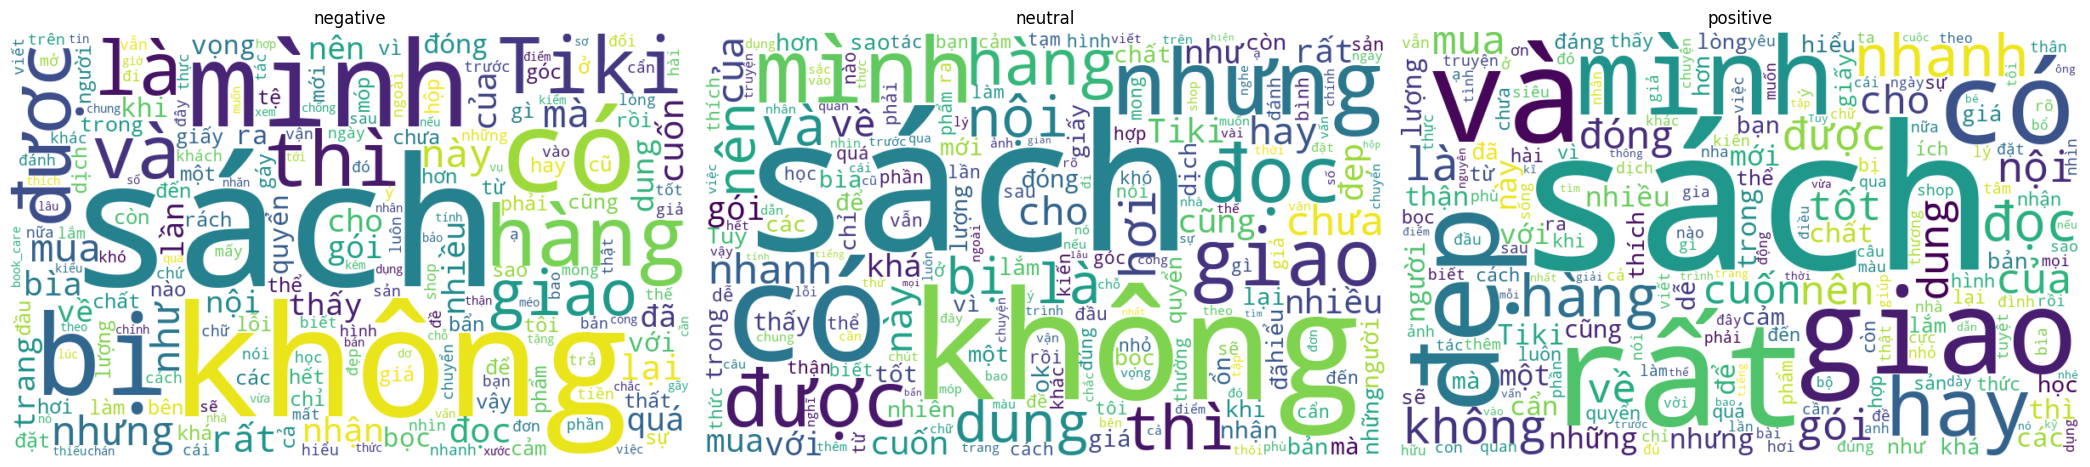

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
for ax, label in zip(axes, SENTIMENT_ORDER):
    text = " ".join(sentiment_subset(df, label)["content"].tolist())
    wc = WordCloud(
        width=800,
        height=500,
        background_color="white",
        collocations=False,
        colormap="viridis",
    ).generate(text if text.strip() else "empty")
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3D Scatter: TF-IDF + t-SNE

In [ ]:
sample_3d = (
    df.groupby("sentiment_name", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 300), random_state=42))
    .reset_index(drop=True)
)
texts_3d = sample_3d["content"].map(normalize_text_for_ngrams).tolist()

tfidf_3d = TfidfVectorizer(max_features=1200, ngram_range=(1, 2), min_df=2)
x_tfidf_3d = tfidf_3d.fit_transform(texts_3d)

n_components_3d = min(50, max(2, x_tfidf_3d.shape[1] - 1))
svd_3d = TruncatedSVD(n_components=n_components_3d, random_state=42)
x_reduced_3d = svd_3d.fit_transform(x_tfidf_3d)

perplexity_3d = min(30, max(5, len(sample_3d) // 10))
tsne_3d = TSNE(
    n_components=3,
    random_state=42,
    perplexity=perplexity_3d,
    init="pca",
    learning_rate="auto",
)
coords_3d = tsne_3d.fit_transform(x_reduced_3d)

plot_df_3d = sample_3d.copy()
plot_df_3d["x"] = coords_3d[:, 0]
plot_df_3d["y"] = coords_3d[:, 1]
plot_df_3d["z"] = coords_3d[:, 2]

C:\Users\PC\AppData\Local\Temp\ipykernel_18572\1435586877.py:3: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [ ]:
fig = px.scatter_3d(
    plot_df_3d,
    x="x",
    y="y",
    z="z",
    color="sentiment_name",
    color_discrete_map=SENTIMENT_COLORS,
    opacity=0.7,
    title="3D text embedding space (TF-IDF + t-SNE)",
)
fig.update_layout(template="plotly_white")
fig.show()

## Notes

- The dashboard is train-only.
- Emoji counts are computed from `content_raw`.
- N-grams, word clouds, and embeddings are computed from cleaned `content`.
- `PyGWalker` requires a notebook runtime with interactive widgets support.